In [1]:
import pandas as pd
print("Jupyter is working inside VS Code!")



Jupyter is working inside VS Code!


In [117]:


# Load CSV file
df = pd.read_csv("out.csv")

# Quick look
df.head()
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1189 entries, 0 to 1188
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   filename              1189 non-null   object 
 1   judge_folder          1189 non-null   object 
 2   case_no               639 non-null    object 
 3   case_type             433 non-null    object 
 4   date                  1088 non-null   object 
 5   hearing_date          993 non-null    object 
 6   petitioner            935 non-null    object 
 7   respondent            936 non-null    object 
 8   advocates_petitioner  298 non-null    object 
 9   advocates_respondent  222 non-null    object 
 10  aors                  523 non-null    object 
 11  judges                1080 non-null   object 
 12  bench_size            1080 non-null   float64
 13  judgment_author       1080 non-null   object 
 14  originating_court     45 non-null     object 
 15  originating_case_no  

(1189, 25)

In [3]:
df.isna().sum()


filename                   0
judge_folder               0
case_no                  550
case_type                756
date                     101
hearing_date             196
petitioner               254
respondent               253
advocates_petitioner     891
advocates_respondent     967
aors                     666
judges                   109
bench_size               109
judgment_author          109
originating_court       1144
originating_case_no      722
constitutional_refs      557
precedents               611
petition_text             96
sections                 113
outcome                  587
disposition_type         640
relief                  1177
word_count                96
char_count                96
dtype: int64

In [118]:
# These two columns had too many missing values so I dropped them
df = df.drop(columns=['relief', 'originating_court'])


In [5]:
for col in ['case_no','case_type','petitioner','respondent','outcome','disposition_type']:
    df[col] = df[col].fillna("Unknown")


In [119]:
print("Columns in dataset:")
df.columns



Columns in dataset:


Index(['filename', 'judge_folder', 'case_no', 'case_type', 'date',
       'hearing_date', 'petitioner', 'respondent', 'advocates_petitioner',
       'advocates_respondent', 'aors', 'judges', 'bench_size',
       'judgment_author', 'originating_case_no', 'constitutional_refs',
       'precedents', 'petition_text', 'sections', 'outcome',
       'disposition_type', 'word_count', 'char_count'],
      dtype='object')

In [7]:
df[['case_no','case_type','petitioner','respondent','outcome','disposition_type']].head(10)
df.isna().sum()[['case_no','case_type','petitioner','respondent','outcome','disposition_type']]


case_no             0
case_type           0
petitioner          0
respondent          0
outcome             0
disposition_type    0
dtype: int64

In [8]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['hearing_date'] = pd.to_datetime(df['hearing_date'], errors='coerce')
df['bench_size'] = pd.to_numeric(df['bench_size'], errors='coerce')
df['word_count'] = pd.to_numeric(df['word_count'], errors='coerce')
df['char_count'] = pd.to_numeric(df['char_count'], errors='coerce')


In [9]:
df.dtypes[['date','hearing_date','bench_size','word_count','char_count']]


date            datetime64[ns]
hearing_date    datetime64[ns]
bench_size             float64
word_count             float64
char_count             float64
dtype: object

In [10]:
# Clean petitioner/respondent names
df['petitioner'] = df['petitioner'].astype(str).str.replace(r'[^\w\s.,]', '', regex=True).str.strip()
df['respondent'] = df['respondent'].astype(str).str.replace(r'[^\w\s.,]', '', regex=True).str.strip()


In [11]:
df[['petitioner','respondent','judges','judgment_author']].sample(5)


,petitioner,respondent,judges,judgment_author
73,Appellants,Election Commission of Pakistan through its,Justice Syed Mansoor Ali Shah; Justice Jamal K...,Justice Athar Minallah
509,Unknown,Unknown,Justice can take cognizance of an application ...,Justice rightly constituted the Full Court to ...
260,Nadeem Wali in J.Ps.408 4092021 s,The State in all cases s,Justice Jamal Khan Mandokhail\nJustice Syed Ha...,Justice Jamal Khan Mandokhail\nJustice Syed Ha...
904,..,Nazir Ahmad others In both cases,Justice Syed Mansoor Ali Shah\nMrs. Justice Ay...,Justice Syed Mansoor Ali Shah\nMrs. Justice Ay...
1173,Unknown,Unknown,Justice of Pakistan; Justice Nasim Hasan\nShah...,Justice Syed Hasan\nAzhar Rizvi that Chapter X...


In [12]:
df['case_type'] = df['case_type'].str.title().str.strip()
df['outcome'] = df['outcome'].str.lower().str.strip()
df['disposition_type'] = df['disposition_type'].str.title().str.strip()

# Example unify
df['outcome'] = df['outcome'].replace({
    'this appeal is allowed': 'allowed',
    'set aside': 'set aside'
})


In [13]:
df['case_type'].value_counts().head()
df['outcome'].unique()[:10]
df['disposition_type'].value_counts().head()


disposition_type
Unknown      640
Set Aside    487
Allowed       31
Dismissed     31
Name: count, dtype: int64

In [14]:
df = df.drop_duplicates()


In [15]:
df.duplicated().sum()


np.int64(0)

In [16]:
df[['bench_size','word_count','char_count']].describe()


,bench_size,word_count,char_count
count,1080.000000,1093.000000,1093.000000
mean,3.737963,3195.234218,19424.236048
std,6.556862,3869.961125,22964.662363
min,1.000000,246.000000,1425.000000
25%,1.000000,1358.000000,8309.000000
50%,2.000000,2192.000000,13521.000000
75%,3.000000,3562.000000,21754.000000
max,83.000000,53185.000000,313938.000000


In [17]:
df[['bench_size','word_count','char_count']].describe()


,bench_size,word_count,char_count
count,1080.000000,1093.000000,1093.000000
mean,3.737963,3195.234218,19424.236048
std,6.556862,3869.961125,22964.662363
min,1.000000,246.000000,1425.000000
25%,1.000000,1358.000000,8309.000000
50%,2.000000,2192.000000,13521.000000
75%,3.000000,3562.000000,21754.000000
max,83.000000,53185.000000,313938.000000


In [18]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['case_length_days'] = (df['hearing_date'] - df['date']).dt.days


In [19]:
df[['date','hearing_date','year','month','case_length_days']].head(10)


,date,hearing_date,year,month,case_length_days
0,2024-08-08,2024-08-08,2024.0,8.0,0.0
1,2013-05-24,2020-01-28,2013.0,5.0,2440.0
2,NaT,NaT,NaN,NaN,NaN
3,2007-02-21,2024-05-27,2007.0,2.0,6305.0
4,2015-06-05,NaT,2015.0,6.0,NaN
5,NaT,NaT,NaN,NaN,NaN
6,2018-09-13,2020-05-14,2018.0,9.0,609.0
7,2014-11-21,2022-07-02,2014.0,11.0,2780.0
8,2016-09-21,2023-07-06,2016.0,9.0,2479.0
9,2016-10-06,NaT,2016.0,10.0,NaN


In [20]:
df = df[df['bench_size'] <= 10]       # filter unrealistic benches
df = df[df['word_count'] <= 20000]    # filter oversized docs
df = df[df['char_count'] <= 100000]   # filter oversized docs


In [21]:
# See max values before cleaning
print("Before cleaning:")
print("Max bench_size:", df['bench_size'].max())
print("Max word_count:", df['word_count'].max())
print("Max char_count:", df['char_count'].max())


Before cleaning:
Max bench_size: 10.0
Max word_count: 15718.0
Max char_count: 96104.0


In [22]:
print("Remaining rows:", len(df))



Remaining rows: 996


In [93]:
df.to_csv("cleaned_out.csv", index=False)


In [26]:
df.to_csv("cleaned_out.csv", index=False)


In [27]:
# Categorical/text columns → fill with "Unknown"
cat_cols = [
    'aors', 'advocates_petitioner', 'advocates_respondent',
    'originating_case_no', 'constitutional_refs', 'precedents'
]
df[cat_cols] = df[cat_cols].fillna("Unknown")

# Date column → stay as datetime with NaT for missing
df['hearing_date'] = pd.to_datetime(df['hearing_date'], errors='coerce')


In [28]:
df['petition_text'] = df['petition_text'].astype(str)

# Optional: drop rows where text is suspiciously short (like just a number)
df = df[df['petition_text'].str.len() > 10]


In [29]:
df['case_length_days'] = (df['hearing_date'] - df['date']).dt.days


In [30]:
# Recalculate safely
df['case_length_days'] = (df['hearing_date'] - df['date']).dt.days

# If you want NaN to stay
df['case_length_days'] = df['case_length_days'].fillna(-1)  # use -1 to mark "no hearing"

# OR if you want them as 0
df['case_length_days'] = df['case_length_days'].fillna(0)


In [31]:
print(df[['hearing_date','aors','advocates_petitioner','advocates_respondent']].head(10))
print(df['petition_text'].head(10))
print(df['case_length_days'].value_counts().head(10))


   hearing_date                                               aors  \
0    2024-08-08  For the State: Ms. Chand Bibi,; Amicus Curiae:...   
1    2020-01-28                                            Unknown   
3    2024-05-27                                                  .   
4           NaT                                                  .   
6    2020-05-14                                            Unknown   
7    2022-07-02                     .; Date of Hearing: 07.02.2022   
8    2023-07-06                                               .; .   
9           NaT                                                  .   
10   2021-08-12                                            Unknown   
11   2021-02-11                        Mr. Liaquat Ali Tareen, ASC   

   advocates_petitioner           advocates_respondent  
0               Unknown                        Unknown  
1               Unknown                        Unknown  
3               Unknown  Mr. Tariq Ahmed Mian, ASC via  
4

In [32]:
df['aors'] = df['aors'].replace({'.': 'Unknown', '.; .': 'Unknown'}).fillna("Unknown")


In [33]:
df['advocates_petitioner'] = df['advocates_petitioner'].replace('.', 'Unknown').fillna("Unknown")
df['advocates_respondent'] = df['advocates_respondent'].replace('.', 'Unknown').fillna("Unknown")


In [34]:
df['petition_text'] = df['petition_text'].astype(str)

# Replace numeric-only texts with Unknown
df.loc[df['petition_text'].str.isnumeric(), 'petition_text'] = "Unknown"

# Drop very short junk text
df = df[df['petition_text'].str.len() > 20]


In [35]:
df['case_length_days'] = (df['hearing_date'] - df['date']).dt.days


In [36]:
print(df['aors'].value_counts().head(10))
print(df['petition_text'].head(5))
print(df['case_length_days'].describe())


aors
Unknown                                                                                                                                                     615
.; .; For Respondent No. 1 Mr. Amir Javed, ASC                                                                                                                8
(in CPs 20 & 25/25) Mr. Idrees Ashraf Malik, ASC; (in CPs 26 & 27/25) Mr. Hamid Khan, Senior ASC; , has pointed out that CMA No.2168/2025 has been filed      5
For ECP : Mr. Zafar Iqbal, Spl. Secy.                                                                                                                         5
(in CPs 20 & 25/25) Mr. Idrees Ashraf Malik, ASC; (in CPs 26 & 27/25) Mr. Hamid Khan, Senior ASC                                                              5
ICAs 5-25/23 2; Syed Rifaqat Hussain Shah, AOR; Mr. Zahid Yousaf, AOR; For the Respondents: Sardar M. Latif Khan Khosa, Sr. ASC                               5
For the Respondents: N.R.          

In [37]:
df['aors'] = df['aors'].astype(str).str.strip()

# Replace "." or weird symbols with Unknown
df['aors'] = df['aors'].replace({'.':'Unknown','.; .':'Unknown','/ASC':'Unknown','dinary':'Unknown'})

# If text length < 5 chars → mark as Unknown
df.loc[df['aors'].str.len() < 5, 'aors'] = "Unknown"


In [38]:
df['petition_text'] = df['petition_text'].str.replace(r'\n',' ', regex=True)


In [39]:
# Drop invalid negative durations
df = df[df['case_length_days'] >= 0]


In [40]:
print(df['aors'].value_counts().head(10))
print(df['petition_text'].head(3))
print(df['case_length_days'].describe())


aors
Unknown                                                                                                                                                     558
.; .; For Respondent No. 1 Mr. Amir Javed, ASC                                                                                                                8
(in CPs 20 & 25/25) Mr. Idrees Ashraf Malik, ASC; (in CPs 26 & 27/25) Mr. Hamid Khan, Senior ASC                                                              5
(in CPs 20 & 25/25) Mr. Idrees Ashraf Malik, ASC; (in CPs 26 & 27/25) Mr. Hamid Khan, Senior ASC; , has pointed out that CMA No.2168/2025 has been filed      5
ICAs 5-25/23 2; Syed Rifaqat Hussain Shah, AOR; Mr. Zahid Yousaf, AOR; For the Respondents: Sardar M. Latif Khan Khosa, Sr. ASC                               5
For the Respondents: N.R.                                                                                                                                     4
Ms. Bushra Qamar, ASC; Mr. Salahudd

In [41]:
df.loc[df['aors'].str.lower().str.contains("dinary"), 'aors'] = "Unknown"


In [42]:
df = df[df['case_length_days'] <= 10000]


In [43]:
print(df['aors'].value_counts().head(10))
print(df['petition_text'].head(3))
print(df['case_length_days'].describe())



aors
Unknown                                                                                                                                                     610
.; .; For Respondent No. 1 Mr. Amir Javed, ASC                                                                                                                8
ICAs 5-25/23 2; Syed Rifaqat Hussain Shah, AOR; Mr. Zahid Yousaf, AOR; For the Respondents: Sardar M. Latif Khan Khosa, Sr. ASC                               5
(in CPs 20 & 25/25) Mr. Idrees Ashraf Malik, ASC; (in CPs 26 & 27/25) Mr. Hamid Khan, Senior ASC; , has pointed out that CMA No.2168/2025 has been filed      5
(in CPs 20 & 25/25) Mr. Idrees Ashraf Malik, ASC; (in CPs 26 & 27/25) Mr. Hamid Khan, Senior ASC                                                              5
For the Respondents: N.R.                                                                                                                                     4
Ms. Bushra Qamar, ASC; Mr. Salahudd

In [44]:
df['aors'] = df['aors'].replace({
    '(Absent)': 'Unknown',
    '. In these appeals the AOR has; and AOR can': 'Unknown'
})


In [45]:
print(df['aors'].value_counts().head(10))
print(df['petition_text'].head(3))
print(df['case_length_days'].describe())


aors
Unknown                                                                                                                                                     614
.; .; For Respondent No. 1 Mr. Amir Javed, ASC                                                                                                                8
ICAs 5-25/23 2; Syed Rifaqat Hussain Shah, AOR; Mr. Zahid Yousaf, AOR; For the Respondents: Sardar M. Latif Khan Khosa, Sr. ASC                               5
(in CPs 20 & 25/25) Mr. Idrees Ashraf Malik, ASC; (in CPs 26 & 27/25) Mr. Hamid Khan, Senior ASC; , has pointed out that CMA No.2168/2025 has been filed      5
(in CPs 20 & 25/25) Mr. Idrees Ashraf Malik, ASC; (in CPs 26 & 27/25) Mr. Hamid Khan, Senior ASC                                                              5
For the Respondents: N.R.                                                                                                                                     4
Ms. Bushra Qamar, ASC; Mr. Salahudd

In [46]:
# Keep all rows
df['case_length_days'] = (df['hearing_date'] - df['date']).dt.days

# Leave NaN where hearing_date is missing
# (so we don't drop rows)


Matplotlib is building the font cache; this may take a moment.


<Axes: >

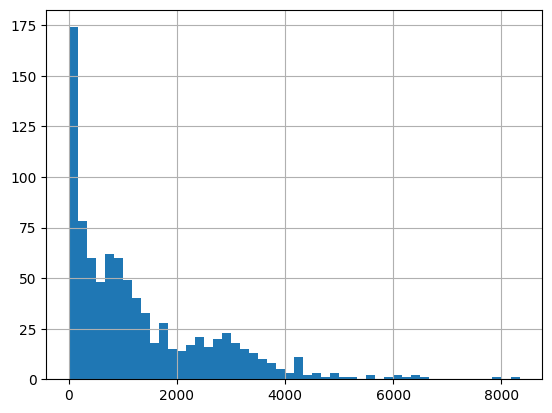

In [47]:
# Example: distribution of case lengths
df[df['case_length_days'].notna()]['case_length_days'].hist(bins=50)


In [48]:
df.to_csv("cleaned_out.csv", index=False)


In [49]:
# If some wrong default date slipped in (e.g., "1970-01-01" or today's date)
# replace them back to NaT
df['hearing_date'] = pd.to_datetime(df['hearing_date'], errors='coerce')


In [50]:
import re

def clean_text(txt):
    if pd.isna(txt):
        return txt
    # remove garbage at start
    txt = re.sub(r'^[\.\,\;\*\s]+', '', txt)
    # collapse multiple spaces
    txt = re.sub(r'\s+', ' ', txt)
    return txt.strip()

df['petition_text'] = df['petition_text'].apply(clean_text)


In [51]:
df = df.drop(columns=['originating_case_no'])


In [55]:
# Define a regex that allows letters, spaces, commas, dots, ASC/AOR etc.
valid_pattern = re.compile(r'^[A-Za-z\s\.\,]*?(ASC|AOR)?[A-Za-z\s\.\,]*$')

def clean_party(val):
    if pd.isna(val):
        return "Unknown"
    val = val.strip()
    # remove pure garbage
    if val in ["...", ".", ";", ""]:
        return "Unknown"
    # keep only valid-looking names
    if valid_pattern.match(val):
        return val
    else:
        return "Unknown"

df['respondent'] = df['respondent'].apply(clean_party)
df['petitioner'] = df['petitioner'].apply(clean_party)


In [53]:
import numpy as np

# Replace 0 with NaN
df['case_length_days'] = df['case_length_days'].replace(0, np.nan)


In [54]:
df['case_length_days'].isna().sum()


np.int64(68)

In [67]:
df.to_csv("cleaned_out.csv", index=False)


In [58]:
df['case_length_days'] = df['case_length_days'].replace(0, np.nan)  # if 0 means missing
df['case_length_days'] = df['case_length_days'].fillna("Unknown")


In [59]:
df.loc[df['hearing_date'] == df['date'], 'hearing_date'] = pd.NaT


In [60]:
import re

def clean_const_refs(x):
    if pd.isna(x):
        return "Unknown"
    x = str(x).strip()
    # If only the word "Article" or similar with no number → Unknown
    if re.fullmatch(r'(?i)article', x):
        return "Unknown"
    return x

df['constitutional_refs'] = df['constitutional_refs'].apply(clean_const_refs)


In [61]:
def clean_party(x):
    if pd.isna(x):
        return "Unknown"
    x = str(x).strip()
    # Remove garbage
    if x in ["...", "..", ".", ";", "ar", ":", ""] or len(x) < 3:
        return "Unknown"
    return x

df['petitioner'] = df['petitioner'].apply(clean_party)
df['respondent'] = df['respondent'].apply(clean_party)


In [64]:
def clean_const_refs(x):
    if pd.isna(x):
        return "Unknown"
    x = str(x).strip()
    # If entry starts with 'Article' but has no number
    if re.fullmatch(r'(?i)article[\s.,]*', x):
        return "Unknown"
    return x

df['constitutional_refs'] = df['constitutional_refs'].apply(clean_const_refs)


In [65]:
def clean_aors(x):
    if pd.isna(x):
        return "Unknown"
    x = str(x).strip()
    # Remove junk
    if x in ["...", "..", ".", ";", "N.R.", "N.R", "nr", "NR"]:
        return "Unknown"
    # If it's just a date (yyyy-mm-dd or dd.mm.yyyy)
    if re.fullmatch(r'\d{4}-\d{2}-\d{2}', x) or re.fullmatch(r'\d{2}[./-]\d{2}[./-]\d{4}', x):
        return "Unknown"
    return x

df['aors'] = df['aors'].apply(clean_aors)


In [66]:
df['hearing_date'] = df['hearing_date'].fillna("Unknown")


In [68]:
def clean_party(x):
    if pd.isna(x): 
        return "Unknown"
    x = str(x).strip()
    # Remove junk patterns
    if re.fullmatch(r'[.\s]*', x) or "etc" in x.lower() or "case" in x.lower():
        return "Unknown"
    # Keep names only (basic rule: at least one capitalized word)
    if re.search(r'[A-Z][a-z]+', x):
        return x
    return "Unknown"

df['petitioner'] = df['petitioner'].apply(clean_party)
df['respondent'] = df['respondent'].apply(clean_party)


In [69]:
def clean_aors(x):
    if pd.isna(x): 
        return "Unknown"
    x = str(x).strip()
    # Drop junk
    if x in ["Unknown", "N.R.", "N.R", ".", "..", "..."]:
        return "Unknown"
    # Remove case refs/dates
    x = re.sub(r'\(.*?\)', '', x)   # remove (CA 94/2008) etc.
    x = re.sub(r'\d{1,2}[./-]\d{1,2}[./-]\d{4}', '', x)  # remove dates
    x = re.sub(r'Date of hearing.*', '', x, flags=re.I) # remove "Date of hearing..."
    return x.strip() if x.strip() else "Unknown"

df['aors'] = df['aors'].apply(clean_aors)


In [70]:
print(df['petitioner'].value_counts().head(20))
print(df['respondent'].value_counts().head(20))
print(df['aors'].value_counts().head(20))
print(df['constitutional_refs'].value_counts().head(20))


petitioner
Unknown                                    427
Petitioners                                 44
Appellants                                  30
... Petitioners                              6
.... Petitioners                             6
others Appellants                            5
.Petitioners                                 4
....Petitioners                              4
...Petitioners                               4
Muhammad Shafique s                          2
Muhammad Riaz                                2
Rizwan Rasheed  another ... s                2
Muhammad Naeem Khan  another Appellants      2
Ahmad Sikander                               2
Abdul Khaliq. ...s                           2
Department Quetta                            2
Islamabad and others                         2
Khizar Hayat s                               2
Ghulam Mustafa s                             2
Asjad Ullah s                                2
Name: count, dtype: int64
respondent
Unknown     

In [71]:
def classify_ref(x):
    if pd.isna(x) or str(x).strip().lower() in ["unknown", "nan"]:
        return "Unknown"
    x = str(x).strip()
    if re.fullmatch(r"(?i)article", x):  # case-insensitive "article"
        return "Just Article"
    elif re.match(r"(?i)article\s*\d+", x):  # Article followed by number
        return "Article with Number"
    else:
        return "Other"

# Apply classification
df["Ref_Type"] = df[col].apply(classify_ref)

# Count occurrences
counts = df["Ref_Type"].value_counts()
print(counts)

Ref_Type
Other      442
Unknown    439
Name: count, dtype: int64


In [74]:
import pandas as pd
import re



def classify_ref(x):
    if pd.isna(x) or str(x).strip().lower() in ["unknown", "nan"]:
        return "Unknown"
    x = str(x).strip()

    # Case: exactly "Article" (ignoring spaces and case)
    if re.fullmatch(r"(?i)article\s*", x):
        return "Just Article"

    # Case: Article followed by number (handles Article 25, Article-25, ARTICLE 25 etc.)
    elif re.match(r"(?i)article[\s\-\.]*\d+", x):
        return "Article with Number"

    else:
        return "Other"

# Apply classification
df["Ref_Type"] = df["constitutional_refs"].apply(classify_ref)

# Show clean output without "Name:" and "dtype:"
print(df["Ref_Type"].value_counts().to_string())


Ref_Type
Article with Number    486
Unknown                395


In [76]:
# See unique values that start with "Article"
print(df["constitutional_refs"].dropna().unique()[:50])


['Article\n128; Article 188; Article 2; Article 128' 'Article 185'
 'Unknown' 'Article 185; Article 17' 'Article 185; Article 129'
 'Article 78' 'Article 72; Article 90; Article 187' 'Article\n185'
 'Article 184; Article 100' 'Article\n185; Article 185'
 'Article\n199; Article 185; Article 199' 'Article\n185; Article 129'
 'Article\n199; Article 185' 'Article 78; Article 185'
 'Article 185; Article 199' 'Article 191A' 'Article\n185; Article 199'
 'Article 184; Article 9'
 'Article 268; Article 203; Article 175; Article 8'
 'Article 72; Article 2; Article 89' 'Article 162'
 'Article 185; Article 91; Article 49; Article 128' 'Article 25'
 'Article 95; Article 79; Article\n79; Article\n95' 'Article 199'
 'Article 51; Article 106' 'Article\n115' 'Article\n199; Article 199'
 'Article 10' 'Article 24; Article 199'
 'Article 37; Article 35; Article 7; Article 199; Article 29'
 'Article 192; Article 175; Article 199'
 'Article\n199; article 2; Article 212; Article 199'
 'Article 185; Article 2

In [77]:
# Remove \n and replace with space in the column
df["constitutional_refs"] = df["constitutional_refs"].astype(str).str.replace("\n", " ", regex=False)

# Now check again
print(df["constitutional_refs"].head(20))


0     Article 128; Article 188; Article 2; Article 128
1                                          Article 185
3                                              Unknown
6                              Article 185; Article 17
7                             Article 185; Article 129
8                                           Article 78
10                 Article 72; Article 90; Article 187
11                                             Unknown
15                                         Article 185
18                                         Article 185
22                                         Article 185
23                                         Article 185
25                            Article 184; Article 100
26                                             Unknown
30                            Article 185; Article 185
31                                         Article 185
32                                         Article 185
34                                         Article 185
36        

In [78]:
print(df['petitioner'].value_counts().head(20))
print(df['respondent'].value_counts().head(20))
print(df['aors'].value_counts().head(20))
print(df['constitutional_refs'].value_counts().head(20))


petitioner
Unknown                                    427
Petitioners                                 44
Appellants                                  30
... Petitioners                              6
.... Petitioners                             6
others Appellants                            5
.Petitioners                                 4
....Petitioners                              4
...Petitioners                               4
Muhammad Shafique s                          2
Muhammad Riaz                                2
Rizwan Rasheed  another ... s                2
Muhammad Naeem Khan  another Appellants      2
Ahmad Sikander                               2
Abdul Khaliq. ...s                           2
Department Quetta                            2
Islamabad and others                         2
Khizar Hayat s                               2
Ghulam Mustafa s                             2
Asjad Ullah s                                2
Name: count, dtype: int64
respondent
Unknown     

In [79]:
def clean_petitioner(x):
    if pd.isna(x): 
        return "Unknown"
    x = str(x).strip()

    # Garbage or placeholders
    if x.lower() in ["petitioners", "appellants", "others appellants"]:
        return "Unknown"
    if re.fullmatch(r'[.\s]*', x):  # only dots/spaces
        return "Unknown"

    # Remove "another", "others", trailing 's', and dots
    x = re.sub(r'\b(another|others)\b', '', x, flags=re.I)
    x = re.sub(r'\.{2,}', '', x)   # remove ...
    x = re.sub(r'\bs\b$', '', x)   # trailing 's'

    # Org type words → not person
    if any(org in x.lower() for org in ["department", "ministry", "islamabad", "govt", "state"]):
        return "Unknown"

    return x.strip().title() if x.strip() else "Unknown"

df['petitioner'] = df['petitioner'].apply(clean_petitioner)


In [80]:
def clean_respondent(x):
    if pd.isna(x): 
        return "Unknown"
    x = str(x).strip()

    # Junk
    if re.fullmatch(r'[.\s]*', x) or "article" in x.lower():
        return "Unknown"

    # Generic labels
    if x.lower() in ["respondents", "appellants"]:
        return "Unknown"

    return x.strip().title() if x.strip() else "Unknown"

df['respondent'] = df['respondent'].apply(clean_respondent)


In [81]:
print(df['petitioner'].value_counts().head(30))
print(df['respondent'].value_counts().head(30))


petitioner
Unknown                             531
Petitioners                          22
.Petitioners                          4
Khizar Hayat                          3
Appellantspetitioners                 3
Appellants                            2
Muhammad Yousaf                       2
Muhammad Iqbal                        2
Muhammad Naeem Khan   Appellants      2
Muhammad Shafique                     2
Rizwan Rasheed                        2
Karachi                               2
Applicant                             2
Muhammad Riaz                         2
Ahmad Sikander                        2
Abdul Khaliq.                         2
.Appellants                           2
Muslim Commercial Bank Limited        2
Ghulam Mustafa                        2
Asjad Ullah                           2
Lahore                                2
. Petitioners                         2
Abdul Aziz                            2
Imran Ahmad Khan Niazi                1
Gohar Ali Khan               

In [82]:
import re

def clean_respondent(x):
    if pd.isna(x):
        return "Unknown"
    
    x = str(x).strip()

    # Standardize Unknowns
    if re.fullmatch(r"(?i)unknown|nan", x):
        return "Unknown"

    # Remove "Respondent", "Respondents", "Respondentfs", case-insensitive
    x = re.sub(r"(?i)\brespondents?\b", "", x)
    x = re.sub(r"(?i)\brespondentfs?\b", "", x)

    # Remove "etc", "etc.", "others", "another", "s" (loose endings)
    x = re.sub(r"(?i)\b(etc|etc\.|others?|another|s)\b", "", x)

    # Remove "through ..." (like "through Secretary", "through LRs")
    x = re.sub(r"(?i)\bthrough.*", "", x)

    # Remove extra punctuation and multiple spaces
    x = re.sub(r"[.,;]+", " ", x)
    x = re.sub(r"\s{2,}", " ", x)

    return x.strip()

# Apply cleaning
df["Cleaned_Respondent"] = df["respondent"].apply(clean_respondent)

# Check results
print(df[["respondent", "Cleaned_Respondent"]].head(30).to_string())


                                                  respondent                    Cleaned_Respondent
0                      The State And Another ... Respondents                         The State And
1                                              Noor Asghar S                           Noor Asghar
3   Bashir Ahmad Deceased Through Lrs And Others Respondents                 Bashir Ahmad Deceased
6                                                    Unknown                               Unknown
7                                                    Unknown                               Unknown
8                                             Waheed Ahmed .                          Waheed Ahmed
10                              Abdul Hameed Deed Thr. Lrs S             Abdul Hameed Deed Thr Lrs
11                                                   Unknown                               Unknown
15                           Haji Muhammad Riaz And Others S                Haji Muhammad Riaz And
18      Ms

In [83]:
def clean_respondent(x):
    if pd.isna(x):
        return "Unknown"
    
    x = str(x).strip()

    # Normalize case and spacing
    x = x.replace("\n", " ")

    # Standardize Unknowns
    if re.fullmatch(r"(?i)(unknown|nan|\.*respondents?)", x):
        return "Unknown"

    # Remove "through ..." (case-insensitive)
    x = re.sub(r"(?i)\bthrough.*", "", x)

    # Remove "Respondent", "Respondents", "Respondentfs"
    x = re.sub(r"(?i)\brespondents?\b", "", x)
    x = re.sub(r"(?i)\brespondentfs?\b", "", x)

    # Remove "etc", "others", "another"
    x = re.sub(r"(?i)\band\s+(others?|another)\b", "", x)
    x = re.sub(r"(?i)\b(etc|etc\.)\b", "", x)

    # Remove stray "s" at the end
    x = re.sub(r"\bs\b$", "", x)

    # Clean extra punctuation/spaces
    x = re.sub(r"[.,;]+", " ", x)
    x = re.sub(r"\s{2,}", " ", x)

    cleaned = x.strip()

    return cleaned if cleaned else "Unknown"

# Apply
df["Cleaned_Respondent"] = df["respondent"].apply(clean_respondent)

print(df[["respondent", "Cleaned_Respondent"]].head(30).to_string())


                                                  respondent                    Cleaned_Respondent
0                      The State And Another ... Respondents                             The State
1                                              Noor Asghar S                         Noor Asghar S
3   Bashir Ahmad Deceased Through Lrs And Others Respondents                 Bashir Ahmad Deceased
6                                                    Unknown                               Unknown
7                                                    Unknown                               Unknown
8                                             Waheed Ahmed .                          Waheed Ahmed
10                              Abdul Hameed Deed Thr. Lrs S           Abdul Hameed Deed Thr Lrs S
11                                                   Unknown                               Unknown
15                           Haji Muhammad Riaz And Others S                  Haji Muhammad Riaz S
18      Ms

In [84]:
def clean_respondent(x):
    if pd.isna(x):
        return "Unknown"
    
    x = str(x).strip().replace("\n", " ")

    # Standardize Unknowns
    if re.fullmatch(r"(?i)(unknown|nan|\.*respondents?)", x):
        return "Unknown"

    # Remove "through ..." completely
    x = re.sub(r"(?i)\bthrough.*", "", x)

    # Remove "Respondent", "Respondents", "Respondentfs"
    x = re.sub(r"(?i)\brespondents?\b", "", x)
    x = re.sub(r"(?i)\brespondentfs?\b", "", x)

    # Remove "And Others", "Others", "Another"
    x = re.sub(r"(?i)\band\s+others?\b", "", x)
    x = re.sub(r"(?i)\band\s+another\b", "", x)
    x = re.sub(r"(?i)\bothers?\b", "", x)
    x = re.sub(r"(?i)\banother\b", "", x)

    # Remove stray single "s" at end
    x = re.sub(r"\bs\b$", "", x, flags=re.IGNORECASE)

    # Clean punctuation + spaces
    x = re.sub(r"[.,;]+", " ", x)
    x = re.sub(r"\s{2,}", " ", x)

    cleaned = x.strip()
    return cleaned if cleaned else "Unknown"

df["Cleaned_Respondent"] = df["respondent"].apply(clean_respondent)

print(df[["respondent", "Cleaned_Respondent"]].head(30).to_string())


                                                  respondent                    Cleaned_Respondent
0                      The State And Another ... Respondents                             The State
1                                              Noor Asghar S                           Noor Asghar
3   Bashir Ahmad Deceased Through Lrs And Others Respondents                 Bashir Ahmad Deceased
6                                                    Unknown                               Unknown
7                                                    Unknown                               Unknown
8                                             Waheed Ahmed .                          Waheed Ahmed
10                              Abdul Hameed Deed Thr. Lrs S             Abdul Hameed Deed Thr Lrs
11                                                   Unknown                               Unknown
15                           Haji Muhammad Riaz And Others S                    Haji Muhammad Riaz
18      Ms

In [85]:
def clean_respondent(x):
    if pd.isna(x):
        return "Unknown"
    
    x = str(x).strip().replace("\n", " ")

    # Standardize Unknowns
    if re.fullmatch(r"(?i)(unknown|nan|\.*respondents?)", x):
        return "Unknown"

    # Remove "through ..." completely (including "Thr.")
    x = re.sub(r"(?i)\bthr(?:ough)?\b.*", "", x)

    # Remove Respondent variations
    x = re.sub(r"(?i)\brespondents?\b", "", x)
    x = re.sub(r"(?i)\brespondentfs?\b", "", x)

    # Remove "And Others", "Others", "Another"
    x = re.sub(r"(?i)\band\s+others?\b", "", x)
    x = re.sub(r"(?i)\band\s+another\b", "", x)
    x = re.sub(r"(?i)\bothers?\b", "", x)
    x = re.sub(r"(?i)\banother\b", "", x)

    # Remove stray dangling "and" at end
    x = re.sub(r"\band\b$", "", x, flags=re.IGNORECASE)

    # Remove trailing single 's'
    x = re.sub(r"\bs\b$", "", x, flags=re.IGNORECASE)

    # Clean punctuation + spaces
    x = re.sub(r"[.,;]+", " ", x)
    x = re.sub(r"\s{2,}", " ", x)

    cleaned = x.strip()
    return cleaned if cleaned else "Unknown"

df["Cleaned_Respondent"] = df["respondent"].apply(clean_respondent)

print(df[["respondent", "Cleaned_Respondent"]].head(900
                                                    ).to_string())


                                                                         respondent                                                 Cleaned_Respondent
0                                             The State And Another ... Respondents                                                          The State
1                                                                     Noor Asghar S                                                        Noor Asghar
3                          Bashir Ahmad Deceased Through Lrs And Others Respondents                                              Bashir Ahmad Deceased
6                                                                           Unknown                                                            Unknown
7                                                                           Unknown                                                            Unknown
8                                                                    Waheed Ahmed .           

In [86]:
print(df[["respondent", "Cleaned_Respondent"]].tail
      (900).to_string())

                                                                         respondent                                                 Cleaned_Respondent
0                                             The State And Another ... Respondents                                                          The State
1                                                                     Noor Asghar S                                                        Noor Asghar
3                          Bashir Ahmad Deceased Through Lrs And Others Respondents                                              Bashir Ahmad Deceased
6                                                                           Unknown                                                            Unknown
7                                                                           Unknown                                                            Unknown
8                                                                    Waheed Ahmed .           

In [87]:
import re
import pandas as pd

def clean_petitioner(x):
    if pd.isna(x):
        return "Unknown"
    
    x = str(x).strip()
    
    # Remove dot chains / garbage placeholders
    if re.fullmatch(r"[.\s]+", x):
        return "Unknown"
    
    # Remove known trailing junk words
    x = re.sub(r"\b(Petitioners?|Petitionerfs|Applicants?|Appellants?|Applicant|Respondents?)\b", "", x, flags=re.IGNORECASE)
    x = re.sub(r"\b(in both cases|in all cases|through.*|etc\.?|others?|s)\b", "", x, flags=re.IGNORECASE)
    
    # Remove multiple dots or ellipses
    x = re.sub(r"\.{2,}", "", x)
    
    # Remove extra spaces/commas left behind
    x = re.sub(r"\s{2,}", " ", x).strip(" ,.")
    
    # If empty after cleaning → Unknown
    if x == "" or x.lower() == "unknown":
        return "Unknown"
    
    return x

# Example usage:
df["Cleaned_Petitioner"] = df["petitioner"].apply(clean_petitioner)


In [88]:
df[["petitioner", "Cleaned_Petitioner"]].sample(20)



,petitioner,Cleaned_Petitioner
1022,Unknown,Unknown
486,Unknown,Unknown
666,Muhammad Saleem,Muhammad Saleem
965,Unknown,Unknown
1053,Unknown,Unknown
365,Unknown,Unknown
379,Unknown,Unknown
975,Unknown,Unknown
199,Unknown,Unknown
466,Kashif Aftab Ahmed Abbasi,Kashif Aftab Ahmed Abbasi


In [89]:
import re

def clean_party_name(x):
    if pd.isna(x):
        return "Unknown"
    x = str(x).strip()

    # Remove unwanted words and dots
    x = re.sub(r"\b(Respondents?|Petitioners?|Appellants?|Others?|Through Lrs|Deed Thr)\b", "", x, flags=re.IGNORECASE)
    x = re.sub(r"[.]+", "", x)   # remove extra dots
    x = re.sub(r"\s+", " ", x)   # collapse multiple spaces
    
    x = x.strip()

    if x == "" or x.lower() == "....respondents":
        return "Unknown"
    return x

# overwrite the same column
df["petitioner"] = df["petitioner"].apply(clean_party_name)


In [90]:
df[["petitioner"]].sample(20)



,petitioner
1074,Unknown
755,Unknown
999,Unknown
450,Unknown
1064,Muhammad Nawaz
762,Unknown
105,Unknown
837,Muhammad Anwar
766,Muhammad Akhtar Hussain Pirzada
225,Unknown


In [91]:
# Check unique values left after cleaning
print(df["petitioner"].unique()[:50])   # show first 50 unique values

# Count how many 'Unknown'
print("Unknown count:", (df["petitioner"] == "Unknown").sum())

# Count how many proper names / institutions remain
print("Non-Unknown count:", (df["petitioner"] != "Unknown").sum())


['Mst Saeeda Begum' 'Unknown' 'Muhammad Arshad Deceased' 'Mst Bibi Fatima'
 'Hasham Khan Deceased' 'Abdul Aziz' 'Moulvi Din Muhammad' 'Ufaid Gul'
 'Shahbaz Gul' 'Irfan Azam And' 'Muhammad Saeed Khan'
 'Allah Rakha Decd Thr Lrs' 'Mst Khairan Bibi' 'Muhammad Asif'
 'Atif Mehmood Kiyani And' 'Arif Fareed' 'Muhammad Iqbal'
 'Ali Madad Jattak' 'Iftikhar Ud Din Decd Through LRs'
 'Syed Ali Ahmed Shah' 'Karachi' 'Moiilui Abdul Fateh'
 'Head Office, Karachi' 'Syed Pervaiz Hussain And' 'Qasim, Karachi'
 'Aamir Afzal And' 'Aminullah And' 'Rto, Faisalabad' 'Dr Muhammad Saleem'
 'Muhammad Yousaf' 'DrFaryal Maqsood And' 'Shaista Habib'
 'Muhammad Suleman' 'Ahmad Ullah And' 'And' 'Muhammad Safeer And'
 'Hameedullah' 'Fida Hussain Saboo' 'Raja Azmat Ali Applicant'
 'Muhammad Usman So Muhammad Arshad' 'Subha Sadiq'
 'The Inspector General Of Police, Punjab' 'Pof Board, Wah Cantt'
 'Secretary, Punjab, Lahore And' 'Muzammal Khan' 'M Hamad Hassan'
 'Rehm Dad' 'Raja Muhammad Owais' 'Raja Tanveer Safdar' '

In [94]:


import pandas as pd
import re

# Example: your dataframe is df with column 'respondent'

def clean_respondent(name):
    if pd.isna(name) or re.fullmatch(r'(\.{2,}|unknown|Unknown|\s*)', str(name).strip()):
        return "Unknown"
    
    # Remove trailing words like 'Respondents', 'Others', 'S', etc.
    name = re.sub(r'\b(Respondents?|Appellants?|Others?|S|etc\.?|through LRs?|Deceased|Deed Thr\.?)\b', '', str(name), flags=re.IGNORECASE)
    
    # Remove extra punctuation and whitespace
    name = re.sub(r'[\.\,]+', '', name).strip()
    
    # Collapse multiple spaces
    name = re.sub(r'\s+', ' ', name)
    
    # If nothing remains after cleaning
    if name == '':
        return "Unknown"
    
    return name

# Apply cleaning in-place
df['respondent'] = df['respondent'].apply(clean_respondent)


In [95]:
df.to_csv("cleaned_out.csv", index=False)

In [96]:
import pandas as pd
import re

# Assuming your dataframe is df and the column is 'aors'
def clean_aors(name):
    if pd.isna(name) or re.fullmatch(r'(\.{1,}|unknown|Unknown|\s*)', str(name).strip()):
        return "Unknown"

    name = str(name).strip()

    # Remove common boilerplate phrases
    name = re.sub(
        r'\b(For the Respondent|For Respondent No\.\d+|For Respondents|For the State|For the Petitioner|For Appellant|In person|a/w|assisted by|along with|Ex-parte|N\.R\.|DAG|ASC|AOR|Addl\.|AGP|DPG|PG|Head Legal|Secretary|Legal|Advocate General|Addl\. AG|Senior ASC|Director|Chief|Spl\. Prosecutor|Deputy|Additional|Council|Not represented|In-person|Other respondents|Petitioner|Complainant|State|Respondent|Respondents)\b', 
        '', name, flags=re.IGNORECASE
    )

    # Remove extra punctuation and whitespace
    name = re.sub(r'[\.;,:/]+', '', name)
    name = re.sub(r'\s+', ' ', name).strip()

    # Collapse multiple spaces
    if name == '':
        return "Unknown"

    return name

# Apply cleaning in-place
df['aors'] = df['aors'].apply(clean_aors)


In [101]:
df.to_csv("cleaned_out.csv", index=False)

In [98]:
import pandas as pd
import re

def clean_aor(name):
    if pd.isna(name):
        return "Unknown"
    
    name = str(name).strip()

    # Keep NR as-is
    if name.upper() == "NR":
        return "NR"

    # Remove common garbage patterns, numbers, titles, etc.
    garbage_patterns = [
        r'\b(For the|For|In person|a/w|assisted by|along with|Ex-parte|Nemo|DG-Law|ASC|AOR|Addl\.|AGP|DPG|PG|Head Legal|Secretary|Legal|Advocate General|Addl\. AG|Senior ASC|Director|Chief|Spl\. Prosecutor|Deputy|Additional|Council|Not represented|Other respondents|Petitioner|Complainant|State|Respondent|Respondents)\b',
        r'\d+',             # Remove any numbers
        r'\(.*?\)',         # Remove anything in brackets
        r'\bICAs?\b',       # Remove ICA, ICA numbers
        r'\bC[Aa]r?l?\b',   # Remove CA/Cr references
        r'[-/&]+',          # Remove hyphens, slashes, ampersand
        r'\.+',             # Remove dots
    ]

    for pattern in garbage_patterns:
        name = re.sub(pattern, '', name, flags=re.IGNORECASE)

    # Remove extra spaces
    name = re.sub(r'\s+', ' ', name).strip()

    # If the result is empty or too short, mark as Unknown
    if len(name) < 3:
        return "Unknown"

    return name

# Apply cleaning in-place
df['aors'] = df['aors'].apply(clean_aor)


In [ ]:
def classify_ref(x):
    if pd.isna(x) or str(x).strip().lower() in ["unknown", "nan"]:
        return "Unknown"
    x = str(x).strip()
    if re.fullmatch(r"(?i)article", x):  # case-insensitive "article"
        return "Just Article"
    elif re.match(r"(?i)article\s*\d+", x):  # Article followed by number
        return "Article with Number"
    else:
        return "Other"

# Apply classification
df["Ref_Type"] = df[col].apply(classify_ref)

# Count occurrences
counts = df["Ref_Type"].value_counts()
print(counts)

Ref_Type
Other      442
Unknown    439
Name: count, dtype: int64


In [100]:
# Drop the extra cleaned columns if they exist
cols_to_remove = ['Cleaned_Petitioner', 'Cleaned_Respondent' , 'Ref_Type']  # add any extra cleaned columns here
for col in cols_to_remove:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Now the original columns contain the cleaned data in-place
print(df.head())


                                            filename  \
0  Offence of Qazf (Enforcement of Hadood) Ord. 1...   
1                                 c.a._1080_2013.pdf   
3                                c.a._138_l_2010.pdf   
6                                c.a._154_l_2018.pdf   
7                                 c.a._1683_2014.pdf   

               judge_folder                                  case_no  \
0             Dr Qibla Ayaz                                  Unknown   
1  Justice Amin-Ud-Din Khan                                  Unknown   
3  Justice Amin-Ud-Din Khan  Civil Appeal Nos. 138-L & 139-L of 2010   
6  Justice Amin-Ud-Din Khan            Civil Appeal No.154-L of 2018   
7  Justice Amin-Ud-Din Khan           Civil Appeal No. 1683 of 2014.   

  case_type       date         hearing_date                petitioner  \
0   Unknown 2024-08-08              Unknown          Mst Saeeda Begum   
1   Unknown 2013-05-24  2020-01-28 00:00:00                   Unknown   
3     Civil

In [102]:
# Convert to datetime and keep only the date
df['hearing_date'] = pd.to_datetime(df['hearing_date'], errors='coerce').dt.date


C:\Users\Arcz\AppData\Local\Temp\ipykernel_13208\948462268.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hearing_date'] = pd.to_datetime(df['hearing_date'], errors='coerce').dt.date


In [103]:
# Convert to datetime first, then format as M/D/YYYY
df['hearing_date'] = pd.to_datetime(df['hearing_date'], errors='coerce').dt.strftime('%-m/%-d/%Y')


In [104]:
# Clean 'outcome' column
df['outcome'] = df['outcome'].str.replace('\n', ' ', regex=True)  # remove newlines
df['outcome'] = df['outcome'].str.strip().str.lower()             # standardize case + strip spaces


In [110]:
# Manual mapping of common variations
df['outcome'] = df['outcome'].replace({
    'appeal is dismissed': 'appeal dismissed',
    'appeal is\n dismissed': 'appeal dismissed',
    'appeal dismissed': 'appeal dismissed',
    'appeal\n dismissed': 'appeal dismissed',
    
    'appeal is allowed': 'appeal allowed',
    'appeal\n allowed': 'appeal allowed',
    'this appeal is allowed': 'appeal allowed',
    
    'set aside': 'set aside',
    'set\naside': 'set aside',
})


In [111]:
df.to_csv("cleaned_out.csv", index=False)

In [112]:
# In analysis.ipynb
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['hearing_date'] = pd.to_datetime(df['hearing_date'], errors='coerce')

df['case_duration_days'] = (df['date'] - df['hearing_date']).dt.days

df.to_csv("cleaned_out.csv", index=False)


In [113]:
print(df['date'].dtype, df['hearing_date'].dtype)


datetime64[ns] datetime64[ns]


In [114]:
# Convert once in analysis
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['hearing_date'] = pd.to_datetime(df['hearing_date'], errors='coerce')
df['case_duration_days'] = (df['date'] - df['hearing_date']).dt.days

df.to_csv("cleaned_out.csv", index=False)


In [115]:
print(df.columns)


Index(['filename', 'judge_folder', 'case_no', 'case_type', 'date',
       'hearing_date', 'petitioner', 'respondent', 'advocates_petitioner',
       'advocates_respondent', 'aors', 'judges', 'bench_size',
       'judgment_author', 'constitutional_refs', 'precedents', 'petition_text',
       'sections', 'outcome', 'disposition_type', 'word_count', 'char_count',
       'year', 'month', 'case_length_days', 'sections_list',
       'case_duration_days'],
      dtype='object')


In [116]:
df['case_duration_days'].describe()
print(df['case_duration_days'].head(20))


0        NaN
1    -2440.0
3    -6305.0
6     -609.0
7    -2780.0
8    -2479.0
10   -2326.0
11   -2288.0
15   -2790.0
18    -900.0
22   -2084.0
23    -895.0
25       NaN
26    -665.0
30   -1669.0
31   -3200.0
32    -142.0
34       NaN
36   -1956.0
37    -650.0
Name: case_duration_days, dtype: float64
